In [ ]:
import pandas as pd
data=pd.read_csv('/content/Online retail.csv')
data

,"shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil"
0,"burgers,meatballs,eggs"
1,chutney
2,"turkey,avocado"
3,"mineral water,milk,energy bar,whole wheat rice..."
4,low fat yogurt
...,...
7495,"butter,light mayo,fresh bread"
7496,"burgers,frozen vegetables,eggs,french fries,ma..."
7497,chicken
7498,"escalope,green tea"


In [ ]:
transaction=data.iloc[:,0].apply(lambda x:x.strip().split(','))

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
te=TransactionEncoder()
te_ary=te.fit(transaction).transform(transaction)

In [ ]:
te_ary

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False]])

In [ ]:
df=pd.DataFrame(te_ary,columns=te.columns_)
df

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from mlxtend.frequent_patterns import apriori
frequent_itemsets=apriori(df,min_support=0.01,use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.020267,(almonds)
1,0.033200,(avocado)
2,0.010800,(barbecue sauce)
3,0.014267,(black tea)
4,0.011467,(body spray)
...,...,...
254,0.011067,"(mineral water, milk, ground beef)"
255,0.017067,"(mineral water, ground beef, spaghetti)"
256,0.015733,"(mineral water, milk, spaghetti)"
257,0.010267,"(mineral water, olive oil, spaghetti)"


In [ ]:
from mlxtend.frequent_patterns import association_rules

In [ ]:
rules=association_rules(frequent_itemsets,metric='lift',min_threshold=1)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(mineral water),(avocado),0.238267,0.033200,0.011467,0.048125,1.449559,1.0,0.003556,1.015680,0.407144,0.044103,0.015438,0.196753
1,(avocado),(mineral water),0.033200,0.238267,0.011467,0.345382,1.449559,1.0,0.003556,1.163629,0.320785,0.044103,0.140620,0.196753
2,(cake),(burgers),0.081067,0.087200,0.011467,0.141447,1.622103,1.0,0.004398,1.063185,0.417349,0.073129,0.059430,0.136473
3,(burgers),(cake),0.087200,0.081067,0.011467,0.131498,1.622103,1.0,0.004398,1.058068,0.420154,0.073129,0.054881,0.136473
4,(chocolate),(burgers),0.163867,0.087200,0.017067,0.104150,1.194377,1.0,0.002777,1.018920,0.194639,0.072934,0.018569,0.149934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,"(mineral water, pancakes)",(spaghetti),0.033733,0.174133,0.011467,0.339921,1.952073,1.0,0.005593,1.251163,0.504751,0.058384,0.200744,0.202885
404,"(pancakes, spaghetti)",(mineral water),0.025200,0.238267,0.011467,0.455026,1.909736,1.0,0.005462,1.397744,0.488682,0.045503,0.284561,0.251576
405,(mineral water),"(pancakes, spaghetti)",0.238267,0.025200,0.011467,0.048125,1.909736,1.0,0.005462,1.024084,0.625373,0.045503,0.023518,0.251576
406,(spaghetti),"(mineral water, pancakes)",0.174133,0.033733,0.011467,0.065850,1.952073,1.0,0.005593,1.034381,0.590560,0.058384,0.033238,0.202885


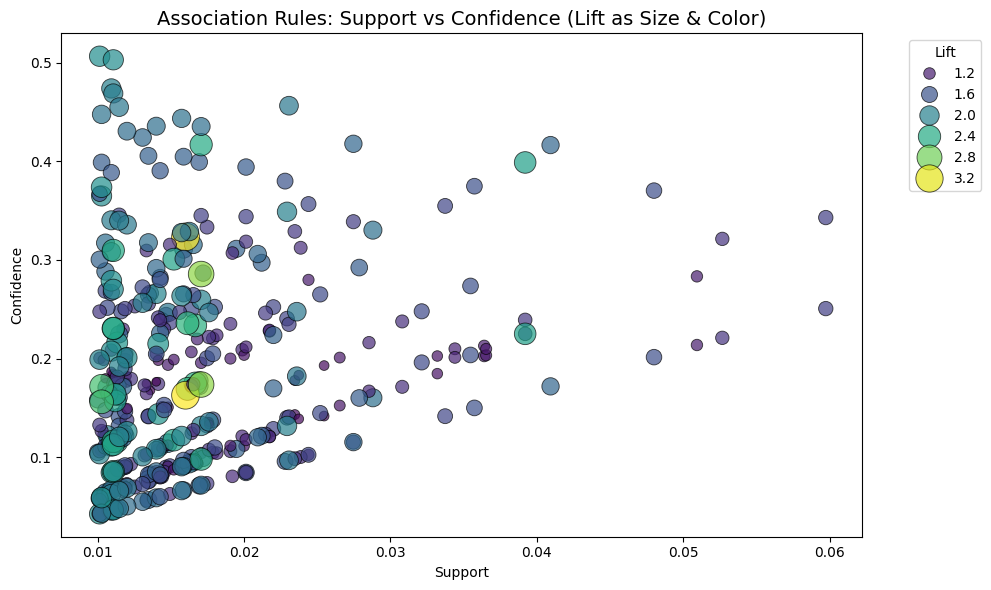

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `strong_rules` is your filtered DataFrame
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rules,
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    palette='viridis',
    sizes=(40, 400),
    alpha=0.7,
    edgecolor='k'
)

plt.title('Association Rules: Support vs Confidence (Lift as Size & Color)', fontsize=14)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
'''
Interpretation of Rules
Interpret the association rules using the three key metrics:
Support: How frequently the itemset appears in all transactions.
Confidence: The probability that item B is purchased when item A is purchased.
Lift: How much more likely items are to occur together compared to random chance

In [16]:
# Sample: Display top 5 strong rules with interpretation
for idx, row in rules.head(5).iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    support = row['support']
    confidence = row['confidence']
    lift = row['lift']

    print(f"Rule: If a customer buys [{antecedents}], they are likely to also buy [{consequents}].")
    print(f" - Support: {support:.2f} → This rule appears in {support*100:.1f}% of all transactions.")
    print(f" - Confidence: {confidence:.2f} → When [{antecedents}] is bought, [{consequents}] is also bought {confidence*100:.1f}% of the time.")
    print(f" - Lift: {lift:.2f} → [{antecedents}] and [{consequents}] are bought together {lift:.2f} times more often than by chance.")
    print("-" * 80)

Rule: If a customer buys [mineral water], they are likely to also buy [avocado].
 - Support: 0.01 → This rule appears in 1.1% of all transactions.
 - Confidence: 0.05 → When [mineral water] is bought, [avocado] is also bought 4.8% of the time.
 - Lift: 1.45 → [mineral water] and [avocado] are bought together 1.45 times more often than by chance.
--------------------------------------------------------------------------------
Rule: If a customer buys [avocado], they are likely to also buy [mineral water].
 - Support: 0.01 → This rule appears in 1.1% of all transactions.
 - Confidence: 0.35 → When [avocado] is bought, [mineral water] is also bought 34.5% of the time.
 - Lift: 1.45 → [avocado] and [mineral water] are bought together 1.45 times more often than by chance.
--------------------------------------------------------------------------------
Rule: If a customer buys [cake], they are likely to also buy [burgers].
 - Support: 0.01 → This rule appears in 1.1% of all transactions.
 - 

In [ ]:
'''

# 1.	What is lift and why is it important in Association rules?
#Lift measures how much more likely items are purchased together than expected by chance, making it crucial for identifying truly meaningful associations in market basket analysis.

#2.	What is support and Confidence. How do you calculate them?
#Support measures how often an itemset appears in transactions, while confidence calculates the likelihood that the consequent is purchased when the antecedent is, both derived from transaction counts.

#3.	What are some limitations or challenges of Association rules mining?
#Association rule mining can produce an overwhelming number of rules, many of which may be trivial or redundant, and it often struggles with sparse data, setting meaningful thresholds, and ensuring business relevance.